# Model Extension

Besides transfering, the PCNtoolkit can also be used to extend models. The difference in the outcome is that an extended model can be used on all sites that were in the reference set, plus the sites in the extension set. The transfered models only work on the data from the extend set. The key thing is that neither method requires access to the reference data; all that is needed is the estimated model parameters. 

The internal process is also quite different, but the syntax is almost the same. Just replace `transfer` with `extend` everywhere, and that's it. 

In [1]:
from pcntoolkit import load_fcon1000, HBR, NormativeModel

from pcntoolkit.util.plotter import plot_centiles_advanced
import pcntoolkit

import pandas as pd
import logging
import warnings


# Suppress some annoying warnings and logs
pymc_logger = logging.getLogger("pymc")
pymc_logger.setLevel(logging.WARNING)
pymc_logger.propagate = False

warnings.simplefilter(
    action="ignore", category=FutureWarning
)
pd.options.mode.chained_assignment = None
pcntoolkit.util.output.Output.set_show_messages(
    False
)


In [4]:
#  Use default likelihood; Normal, with bspline in mu and sigma, and a random intercept for mu
model = NormativeModel(HBR(progressbar=False), save_dir ="../out/models/extend_model")

# Load the FCON data
data = load_fcon1000()
# Drop all but the first three response vars
data=data.sel({"response_vars":data.response_vars[:3]})

# Select a few sites at random for extending
sites_for_extend = ["Berlin_Margulies", "Oxford"]
# Split by those sites
extend_data,reference_data  = data.batch_effects_split({"site":sites_for_extend},names=( "extend", "reference"))
# Split into train and test setss
reference_train, reference_test = reference_data.train_test_split((0.8, 0.2))
extend_train, extend_test = extend_data.train_test_split((0.8, 0.2))

In [5]:
# Fit a model
model.fit_predict(reference_train, reference_test);


c:\Users\kontsi\AppData\Local\anaconda3\envs\ptk-pu25\Lib\site-packages\pytensor\link\c\cmodule.py:2986: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(


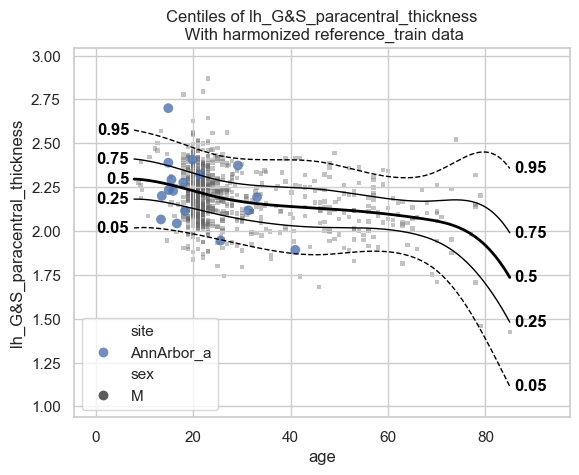

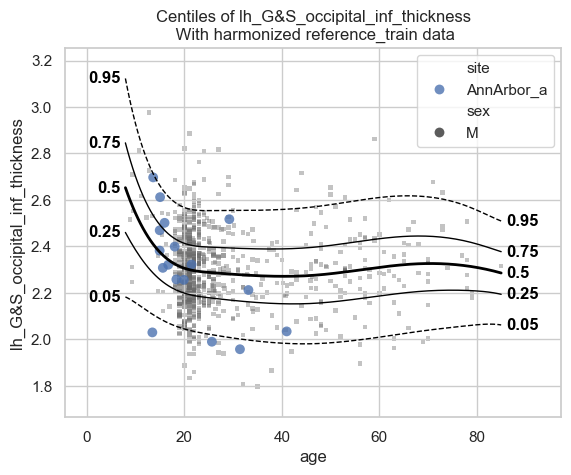

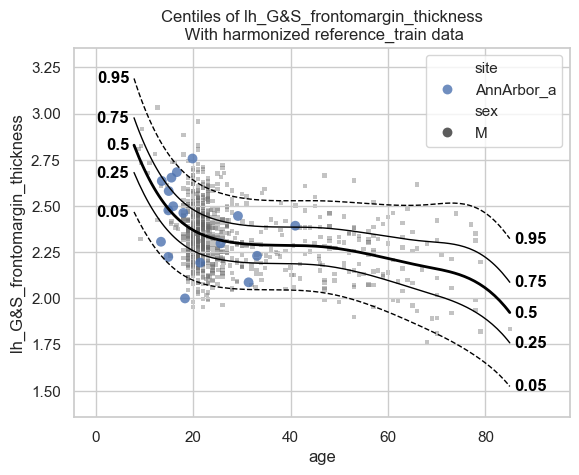

In [6]:
# Show the learned centiles
plot_centiles_advanced(model, scatter_data = reference_train, covariate_range=(10, 80), show_other_data=True)

In [7]:
# Load the model from disk (could also use the model that we just fitted, but this just shows that you can easily load and extend a model)
fitted_model = NormativeModel.load(model.save_dir)

In [8]:
# extend the model and make predictions 
extended_model = fitted_model.extend_predict(extend_train, extend_test);

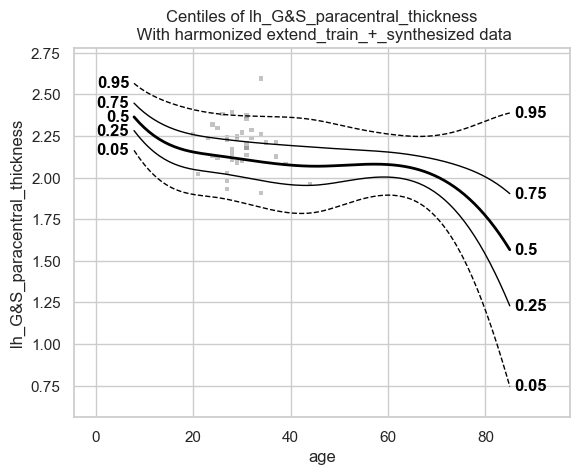

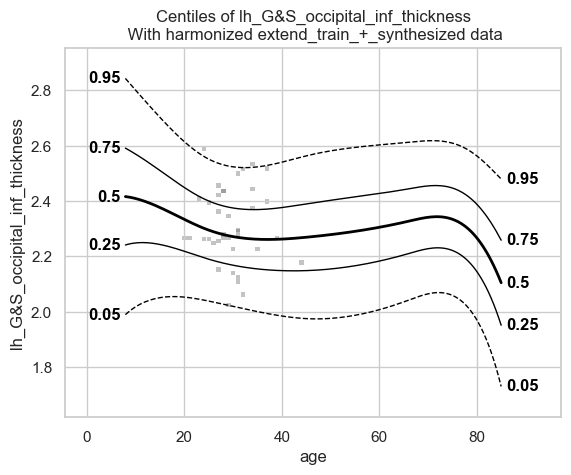

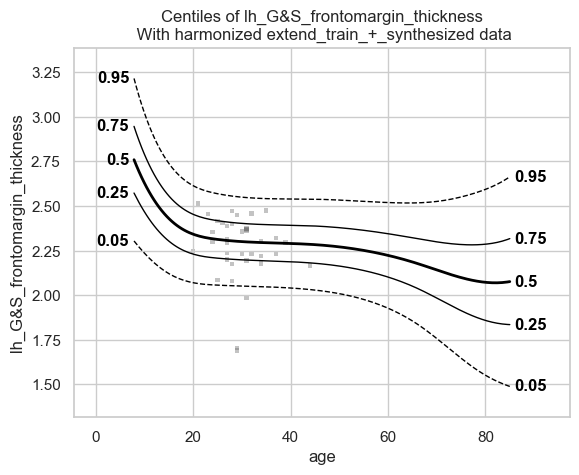

In [9]:
plot_centiles_advanced(extended_model, scatter_data = extend_train, covariate_range=(10, 80), show_other_data=True)

Here we again see that the model is quite capable of making reasonable predictions for data that falls outside the observed age range.
